# Dependencies and imports

In [22]:


!pip install numpy scipy open3d matplotlib scikit-learn networkx tqdm

In [23]:
# ============================================================================
# CELL 2: IMPORTS
# ============================================================================

import numpy as np
import open3d as o3d
from scipy.spatial import KDTree
from scipy.spatial.distance import cdist
from scipy.optimize import minimize, linear_sum_assignment
from sklearn.linear_model import RANSACRegressor
from sklearn.neighbors import NearestNeighbors
import networkx as nx
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from tqdm import tqdm
import os
import time
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)

# Functions for point clouds

In [45]:
# ============================================================================
# CELL 3: FONCTIONS UTILITAIRES
# ============================================================================

def load_point_cloud(file_path):
    """Charge un nuage de points depuis un fichier."""
    if not os.path.exists(file_path):
        raise FileNotFoundError(f'Fichier introuvable : {file_path}')
    pcd = o3d.io.read_point_cloud(file_path)
    if not pcd.has_points():
        raise ValueError(f'Aucun point trouvé dans {file_path}')
    return pcd

def save_point_cloud(pcd, file_path):
    """Sauvegarde un nuage de points dans un fichier."""
    os.makedirs(os.path.dirname(file_path) if os.path.dirname(file_path) else '.', exist_ok=True)
    o3d.io.write_point_cloud(file_path, pcd)

def visualize_point_clouds_matplotlib(pcds, titles=None, colors=None, figsize=(12, 8)):
    """
    Visualise des nuages de points en 3D avec Matplotlib.
    Fonctionne dans Jupyter sans besoin de GLFW/OSMesa.
    """
    if titles is None:
        titles = [f'Cloud {i+1}' for i in range(len(pcds))]
    if colors is None:
        colors = ['r', 'g', 'b', 'c', 'm', 'y'][:len(pcds)]

    fig = plt.figure(figsize=figsize)
    ax = fig.add_subplot(111, projection='3d')

    for i, (pcd, title, color) in enumerate(zip(pcds, titles, colors)):
        points = np.asarray(pcd.points)
        ax.scatter(points[:, 0], points[:, 1], points[:, 2],
                  c=color, s=5, alpha=0.6, label=title)

    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')
    ax.legend()
    ax.set_title('Visualisation 3D des nuages de points')
    plt.tight_layout()
    plt.show()
    return fig

def visualize_point_clouds(pcds, titles=None, colors=None, width=1200, height=800):
    """Visualise un ou plusieurs nuages de points."""
    if titles is None:
        titles = [f'Nuage {i+1}' for i in range(len(pcds))]
    if colors is None:
        colors = [[1, 0, 0], [0, 1, 0], [0, 0, 1], [1, 1, 0], [1, 0, 1], [0, 1, 1]][:len(pcds)]

    colored_pcds = []
    for i, pcd in enumerate(pcds):
        pcd_copy = o3d.geometry.PointCloud(pcd)
        if pcd_copy.has_normals():
            pcd_copy.normals = o3d.utility.Vector3dVector()
        if not pcd_copy.has_colors():
            pcd_copy.paint_uniform_color(colors[i])
        colored_pcds.append(pcd_copy)

    combined = o3d.geometry.PointCloud()
    for pcd in colored_pcds:
        combined += pcd

    vis = o3d.visualization.Visualizer()
    vis.create_window(width=width, height=height)

    for pcd in colored_pcds:
        vis.add_geometry(pcd)

    ctr = vis.get_view_control()
    ctr.set_zoom(0.8)
    ctr.rotate(20.0, 0.0)
    ctr.rotate(0.0, -30.0)

    vis.run()
    vis.destroy_window()

def compute_centroid(points):
    """Calcule le centroïde d'un ensemble de points."""
    return np.mean(points, axis=0)

def compute_covariance_matrix(points):
    """Calcule la matrice de covariance d'un ensemble de points."""
    centroid = compute_centroid(points)
    centered = points - centroid
    return np.dot(centered.T, centered) / len(points)

def compute_pca(points):
    """Effectue une Analyse en Composantes Principales."""
    cov_matrix = compute_covariance_matrix(points)
    eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)
    idx = np.argsort(eigenvalues)[::-1]
    eigenvalues = eigenvalues[idx]
    eigenvectors = eigenvectors[:, idx]
    return eigenvalues, eigenvectors

# Define Supervoxels



In [46]:
# ============================================================================
# CELL 4: SEGMENTATION EN SUPERVOXELS
# ============================================================================

def supervoxel_segmentation(pcd, voxel_resolution=0.2, seed_resolution=1.0,
                         color_importance=0.2, spatial_importance=1.0, normal_importance=1.0):
    """Segmentation en supervoxels - CORRIGÉE."""
    start_time = time.time()
    print(f'Début de la segmentation avec {len(pcd.points)} points...')

    # Sous-échantillonnage si nécessaire
    if voxel_resolution > 0:
        pcd_down = pcd.voxel_down_sample(voxel_resolution)
    else:
        pcd_down = pcd

    points = np.asarray(pcd_down.points)  # On travaille sur le nuage sous-échantillonné

    # Estimation des normales
    if not pcd_down.has_normals():
        pcd_down.estimate_normals(search_param=o3d.geometry.KDTreeSearchParamHybrid(radius=0.1, max_nn=30))
    normals = np.asarray(pcd_down.normals)

    # Construction du KDTree
    tree = KDTree(points)

    # Génération des graines
    if seed_resolution > 0:
        min_bound = np.min(points, axis=0)
        max_bound = np.max(points, axis=0)
        x_range = np.arange(min_bound[0], max_bound[0], seed_resolution)
        y_range = np.arange(min_bound[1], max_bound[1], seed_resolution)
        z_range = np.arange(min_bound[2], max_bound[2], seed_resolution)
        xx, yy, zz = np.meshgrid(x_range, y_range, z_range, indexing='ij')
        seed_points = np.column_stack([xx.ravel(), yy.ravel(), zz.ravel()])
        mask = ((seed_points[:, 0] >= min_bound[0]) & (seed_points[:, 0] <= max_bound[0]) &
                (seed_points[:, 1] >= min_bound[1]) & (seed_points[:, 1] <= max_bound[1]) &
                (seed_points[:, 2] >= min_bound[2]) & (seed_points[:, 2] <= max_bound[2]))
        seed_points = seed_points[mask]
        _, seed_indices = tree.query(seed_points, k=1)
        seed_points = points[seed_indices]
    else:
        seed_indices = np.arange(len(points))
        seed_points = points.copy()

    print(f'Généré {len(seed_points)} graines')

    # Segmentation
    labels = -1 * np.ones(len(points), dtype=int)
    clusters = []

    for seed_idx in tqdm(seed_indices, desc='Traitement des graines'):
        if labels[seed_idx] != -1:
            continue
        cluster_points = [seed_idx]
        labels[seed_idx] = len(clusters)
        changed = True
        while changed:
            changed = False
            current_size = len(cluster_points)
            for point_idx in cluster_points:
                neighbor_indices = tree.query_ball_point(points[point_idx], r=seed_resolution)
                for neighbor_idx in neighbor_indices:
                    if labels[neighbor_idx] == -1:
                        point = points[point_idx]
                        neighbor = points[neighbor_idx]
                        spatial_dist = np.linalg.norm(point - neighbor)
                        spatial_sim = np.exp(-spatial_dist / seed_resolution)
                        normal_sim = 0
                        if pcd_down.has_normals():
                            normal = normals[point_idx]
                            neighbor_normal = normals[neighbor_idx]
                            normal_sim = 1 - np.arccos(np.clip(np.dot(normal, neighbor_normal), -1, 1)) / np.pi
                        color_sim = 0
                        if pcd_down.has_colors():
                            colors_arr = np.asarray(pcd_down.colors)
                            color_sim = 1 - np.linalg.norm(colors_arr[point_idx] - colors_arr[neighbor_idx]) / np.sqrt(3)
                        similarity = (spatial_importance * spatial_sim +
                                     normal_importance * normal_sim +
                                     color_importance * color_sim) / (spatial_importance + normal_importance + color_importance)
                        if similarity > 0.5:
                            labels[neighbor_idx] = len(clusters)
                            cluster_points.append(neighbor_idx)
                            changed = True
            if len(cluster_points) == current_size:
                break
        clusters.append(cluster_points)

    # Calcul des centroïdes et normales
    num_clusters = len(clusters)
    centroids = np.zeros((num_clusters, 3))
    cluster_normals = np.zeros((num_clusters, 3))

    for i, cluster_indices in enumerate(clusters):
        cluster_pts = points[cluster_indices]
        centroids[i] = compute_centroid(cluster_pts)
        if pcd_down.has_normals():
            cluster_normals[i] = np.mean(normals[cluster_indices], axis=0)
            cluster_normals[i] /= np.linalg.norm(cluster_normals[i])
        else:
            _, eigenvectors = compute_pca(cluster_pts)
            cluster_normals[i] = eigenvectors[:, 2]

    supervoxel_data = {
        'labels': labels,
        'supervoxels': clusters,
        'centroids': centroids,
        'normals': cluster_normals,
        'num_supervoxels': num_clusters,
        'downsampled_pcd': pcd_down
    }

    elapsed = time.time() - start_time
    print(f'Segmentation terminée en {elapsed:.2f} secondes ({num_clusters} supervoxels)')
    return supervoxel_data

def visualize_supervoxels(pcd, supervoxel_data, colors=None):
    """Visualise les supervoxels - CORRIGÉE."""
    # Utilise le nuage sous-échantillonné si disponible
    if 'downsampled_pcd' in supervoxel_data:
        points = np.asarray(supervoxel_data['downsampled_pcd'].points)
    else:
        points = np.asarray(pcd.points)

    labels = supervoxel_data['labels']
    num_clusters = supervoxel_data['num_supervoxels']

    # Vérification de cohérence
    if len(labels) != len(points):
        min_len = min(len(labels), len(points))
        points = points[:min_len]
        labels = labels[:min_len]
        print(f"Ajustement : {len(labels)} labels pour {len(points)} points")

    if colors is None:
        colors = np.random.rand(num_clusters, 3)

    point_colors = np.zeros((len(points), 3))
    for i in range(num_clusters):
        mask = (labels == i)
        point_colors[mask] = colors[i]

    colored_pcd = o3d.geometry.PointCloud()
    colored_pcd.points = o3d.utility.Vector3dVector(points)
    colored_pcd.colors = o3d.utility.Vector3dVector(point_colors)

    return colored_pcd

# ESF Descriptors

In [47]:
# ============================================================================
# CELL 5: DESCRIPTEURS ESF
# ============================================================================

def compute_esf_descriptor(cluster_points, num_bins=10, num_radii=4, num_sectors=16):
    """Calcule le descripteur ESF pour un ensemble de points."""
    if len(cluster_points) == 0:
        return np.zeros(num_bins * num_radii * num_sectors)

    centroid = compute_centroid(cluster_points)
    centered = cluster_points - centroid

    distances = np.linalg.norm(centered, axis=1)
    max_distance = np.max(distances) if np.max(distances) > 0 else 1.0
    normalized_distances = distances / max_distance

    r = distances
    theta = np.arccos(centered[:, 2] / (r + 1e-10))
    phi = np.arctan2(centered[:, 1], centered[:, 0])
    phi = (phi + 2 * np.pi) % (2 * np.pi)

    descriptor_size = num_bins * num_radii * num_sectors
    descriptor = np.zeros(descriptor_size)

    distance_bins = np.linspace(0, 1, num_bins + 1)
    radial_bins = np.linspace(0, 1, num_radii + 1)
    angular_bins = np.linspace(0, 2 * np.pi, num_sectors + 1)

    for i, d_bin_start in enumerate(distance_bins[:-1]):
        d_bin_end = distance_bins[i + 1]
        in_bin = (normalized_distances >= d_bin_start) & (normalized_distances < d_bin_end)

        for j, r_bin_start in enumerate(radial_bins[:-1]):
            r_bin_end = radial_bins[j + 1]
            in_r_bin = (r / max_distance >= r_bin_start) & (r / max_distance < r_bin_end)

            for k, a_bin_start in enumerate(angular_bins[:-1]):
                a_bin_end = angular_bins[k + 1]
                in_a_bin = (phi >= a_bin_start) & (phi < a_bin_end)

                count = np.sum(in_bin & in_r_bin & in_a_bin)
                idx = i * num_radii * num_sectors + j * num_sectors + k
                descriptor[idx] = count

    descriptor_norm = np.linalg.norm(descriptor)
    if descriptor_norm > 0:
        descriptor = descriptor / descriptor_norm

    return descriptor

def compute_simple_descriptor(cluster_points, num_bins=10):
    """Calcule un descripteur simplifié basé sur l'histogramme des distances."""
    if len(cluster_points) == 0:
        return np.zeros(num_bins)

    centroid = compute_centroid(cluster_points)
    centered = cluster_points - centroid
    distances = np.linalg.norm(centered, axis=1)

    max_distance = np.max(distances) if np.max(distances) > 0 else 1.0
    normalized_distances = distances / max_distance

    hist, _ = np.histogram(normalized_distances, bins=num_bins, range=(0, 1))

    hist_norm = np.linalg.norm(hist)
    if hist_norm > 0:
        hist = hist / hist_norm

    return hist

def compute_descriptors_for_cloud(pcd, supervoxel_data, descriptor_type='simple', **kwargs):
    """Calcule les descripteurs pour tous les supervoxels d'un nuage de points."""
    if descriptor_type == 'esf':
        points = np.asarray(pcd.points)
        supervoxels = supervoxel_data['supervoxels']
        num_supervoxels = supervoxel_data['num_supervoxels']

        descriptors = []
        for i in tqdm(range(num_supervoxels), desc='Calcul des descripteurs ESF'):
            cluster_points = points[supervoxels[i]]
            descriptor = compute_esf_descriptor(cluster_points, **kwargs)
            descriptors.append(descriptor)

        return np.array(descriptors)

    elif descriptor_type == 'simple':
        points = np.asarray(pcd.points)
        supervoxels = supervoxel_data['supervoxels']
        num_supervoxels = supervoxel_data['num_supervoxels']
        num_bins = kwargs.get('num_bins', 10)

        descriptors = []
        for i in tqdm(range(num_supervoxels), desc=f'Calcul des descripteurs {descriptor_type}'):
            cluster_points = points[supervoxels[i]]
            descriptor = compute_simple_descriptor(cluster_points, num_bins)
            descriptors.append(descriptor)

        return np.array(descriptors)

    else:
        raise ValueError(f'Type de descripteur inconnu : {descriptor_type}')

#Graph Construction

In [48]:
# ============================================================================
# CELL 6: CONSTRUCTION DES GRAPHES
# ============================================================================

def build_adjacency_graph(supervoxel_data, search_radius=None):
    """Construit un graphe d'adjacence à partir des centroïdes des supervoxels."""
    centroids = supervoxel_data['centroids']
    num_supervoxels = supervoxel_data['num_supervoxels']

    tree = KDTree(centroids)

    if search_radius is None:
        distances, _ = tree.query(centroids, k=2)
        avg_distance = np.mean(distances[:, 1])
        search_radius = avg_distance * 1.5

    graph = nx.Graph()

    for i in range(num_supervoxels):
        graph.add_node(i, centroid=centroids[i],
                       normal=supervoxel_data['normals'][i] if 'normals' in supervoxel_data else None)

    for i in tqdm(range(num_supervoxels), desc='Construction du graphe d\'adjacence'):
        neighbor_indices = tree.query_ball_point(centroids[i], r=search_radius)

        for j in neighbor_indices:
            if i < j:
                distance = np.linalg.norm(centroids[i] - centroids[j])
                graph.add_edge(i, j, distance=distance)

    print(f'Graphe d\'adjacence construit avec {graph.number_of_nodes()} nœuds et {graph.number_of_edges()} arêtes')
    return graph

def compute_edge_descriptor(supervoxel_data, graph, edge, descriptor_type='angle_distance'):
    """Calcule le descripteur d'une arête du graphe."""
    i, j = edge
    centroids = supervoxel_data['centroids']
    normals = supervoxel_data['normals']

    vec_ij = centroids[j] - centroids[i]
    distance = np.linalg.norm(vec_ij)

    if distance < 1e-10:
        return np.zeros(4)

    unit_vec_ij = vec_ij / distance

    if descriptor_type == 'angle_distance':
        normal_i = normals[i]
        normal_j = normals[j]

        cos_angle_i = np.dot(normal_i, unit_vec_ij)
        angle_i = np.arccos(np.clip(cos_angle_i, -1.0, 1.0))

        cos_angle_j = np.dot(normal_j, -unit_vec_ij)
        angle_j = np.arccos(np.clip(cos_angle_j, -1.0, 1.0))

        cos_angle_n = np.dot(normal_i, normal_j)
        angle_n = np.arccos(np.clip(cos_angle_n, -1.0, 1.0))

        return np.array([angle_i, angle_j, angle_n, distance])

    elif descriptor_type == 'simple':
        cos_angle_n = np.dot(normals[i], normals[j])
        angle_n = np.arccos(np.clip(cos_angle_n, -1.0, 1.0))
        return np.array([angle_n, distance])

    else:
        raise ValueError(f'Type de descripteur d\'arête inconnu : {descriptor_type}')

def compute_edge_descriptors(supervoxel_data, graph, descriptor_type='angle_distance'):
    """Calcule les descripteurs pour toutes les arêtes du graphe."""
    edge_descriptors = {}
    edges = list(graph.edges())

    for edge in tqdm(edges, desc='Calcul des descripteurs d\'arêtes'):
        descriptor = compute_edge_descriptor(supervoxel_data, graph, edge, descriptor_type)
        edge_descriptors[edge] = descriptor

    return edge_descriptors

# compute similarity matrices (vertices/edges/graph)

In [49]:
# ============================================================================
# CELL 7: MATRICES DE SIMILARITÉ
# ============================================================================

def compute_vertex_similarity_matrix(descriptors1, descriptors2, metric='cosine'):
    """Calcule la matrice de similarité entre les nœuds de deux graphes."""
    if metric == 'euclidean':
        distances = cdist(descriptors1, descriptors2, metric='euclidean')
        similarities = 1 / (1 + distances)
    elif metric == 'cosine':
        from sklearn.metrics.pairwise import cosine_similarity
        similarities = cosine_similarity(descriptors1, descriptors2)
    else:
        raise ValueError(f'Métrique inconnue : {metric}')

    return similarities

def compute_edge_similarity_matrix(edge_descriptors1, edge_descriptors2, graph1, graph2, metric='euclidean'):
    """Calcule la matrice de similarité entre les arêtes de deux graphes."""
    edges1 = list(graph1.edges())
    edges2 = list(graph2.edges())

    desc1 = np.array([edge_descriptors1[e] for e in edges1])
    desc2 = np.array([edge_descriptors2[e] for e in edges2])

    if metric == 'euclidean':
        distances = cdist(desc1, desc2, metric='euclidean')
        similarities = 1 / (1 + distances)
    elif metric == 'cosine':
        from sklearn.metrics.pairwise import cosine_similarity
        similarities = cosine_similarity(desc1, desc2)
    else:
        raise ValueError(f'Métrique inconnue : {metric}')

    return similarities

def build_graph_similarity_matrix(supervoxel_data1, supervoxel_data2,
                                  vertex_descriptors1, vertex_descriptors2,
                                  vertex_metric='cosine', edge_descriptor_type='angle_distance',
                                  edge_metric='euclidean', alpha=0.7):
    """Construit la matrice de similarité complète pour l'appariement de graphes."""
    graph1 = build_adjacency_graph(supervoxel_data1)
    graph2 = build_adjacency_graph(supervoxel_data2)

    vertex_sim_matrix = compute_vertex_similarity_matrix(
        vertex_descriptors1, vertex_descriptors2, vertex_metric)

    print(f'Matrice de similarité des nœuds : {vertex_sim_matrix.shape}')

    edge_descriptors1 = compute_edge_descriptors(supervoxel_data1, graph1, edge_descriptor_type)
    edge_descriptors2 = compute_edge_descriptors(supervoxel_data2, graph2, edge_descriptor_type)

    edge_sim_matrix = compute_edge_similarity_matrix(
        edge_descriptors1, edge_descriptors2, graph1, graph2, edge_metric)

    print(f'Matrice de similarité des arêtes : {edge_sim_matrix.shape}')

    combined_matrix = alpha * vertex_sim_matrix

    return vertex_sim_matrix, edge_sim_matrix, combined_matrix, graph1, graph2

# Graph Matching

In [50]:
# ============================================================================
# CELL 8: ALGORITHME DE FRANK-WOLFE
# ============================================================================

def graph_matching_frank_wolfe(similarity_matrix, max_iter=100, tol=1e-6):
    """
    Appariement de graphes avec Frank-Wolfe ou l'algorithme hongrois.
    Utilise l'algorithme hongrois pour les matrices rectangulaires.
    """
    n, m = similarity_matrix.shape

    # Si la matrice est rectangulaire, utiliser l'algorithme hongrois
    if n != m:
        print(f"Matrice rectangulaire {n}x{m} → utilisation de l'algorithme hongrois.")
        row_ind, col_ind = linear_sum_assignment(-similarity_matrix)
        permutation_matrix = np.zeros((n, m))
        for i, j in zip(row_ind, col_ind):
            permutation_matrix[i, j] = 1.0
        return list(zip(row_ind, col_ind)), permutation_matrix

    # Sinon, utiliser Frank-Wolfe (pour les matrices carrées)
    x = np.ones((n, n)) / n

    for iteration in tqdm(range(max_iter), desc='Frank-Wolfe'):
        gradient = 2 * np.dot(similarity_matrix, x)
        row_ind, col_ind = linear_sum_assignment(-gradient)

        s = np.zeros((n, n))
        s[row_ind, col_ind] = 1.0
        d = s - x

        term1 = np.trace(np.dot(x.T, np.dot(similarity_matrix, x)))
        term2 = 2 * np.trace(np.dot(x.T, np.dot(similarity_matrix, d)))
        term3 = np.trace(np.dot(d.T, np.dot(similarity_matrix, d)))

        if term3 < 0:
            gamma = -term2 / (2 * term3)
            gamma = max(0, min(1, gamma))
        else:
            gamma = 1.0

        x_new = x + gamma * d
        improvement = np.trace(np.dot(x_new.T, np.dot(similarity_matrix, x_new))) - term1

        if abs(improvement) < tol:
            print(f'Convergence après {iteration + 1} itérations')
            break

        x = x_new

    permutation_matrix = np.zeros((n, n))
    for i in range(n):
        j = np.argmax(x[i])
        permutation_matrix[i, j] = 1.0

    matches = [(i, np.argmax(x[i])) for i in range(n)]
    return matches, permutation_matrix

def extract_matches_from_permutation(permutation_matrix):
    """Extrait les paires appariées d'une matrice de permutation."""
    n, m = permutation_matrix.shape
    matches = []

    for i in range(n):
        for j in range(m):
            if permutation_matrix[i, j] > 0.5:
                matches.append((i, j))

    return matches

def graph_matching_frank_wolfe(similarity_matrix, max_iter=100, tol=1e-6):
    """Effectue l'appariement de graphes avec Frank-Wolfe."""
    permutation_matrix = frank_wolfe_graph_matching(similarity_matrix, max_iter, tol)
    matches = extract_matches_from_permutation(permutation_matrix)
    return matches, permutation_matrix

# Compute transform (also with RANSAC)

In [51]:
# ============================================================================
# CELL 9: RANSAC POUR L'ÉLIMINATION DES OUTLIERS
# ============================================================================

def apply_ransac_to_matches(source_points, target_points, matches,
                         ransac_n=100, residual_threshold=0.01):
    """Applique RANSAC pour éliminer les outliers des points appariés."""
    if len(matches) == 0:
        return [], None

    src_pts = np.array([source_points[i] for i, j in matches])
    tgt_pts = np.array([target_points[j] for i, j in matches])

    best_inliers = []
    best_error = float('inf')
    best_transform = None

    num_matches = len(matches)

    for _ in tqdm(range(ransac_n), desc='Itérations RANSAC'):
        if num_matches >= 3:
            sample_indices = np.random.choice(num_matches, size=3, replace=False)
        else:
            sample_indices = list(range(num_matches))

        src_sample = src_pts[sample_indices]
        tgt_sample = tgt_pts[sample_indices]

        transform, error = estimate_rigid_transform(src_sample, tgt_sample)

        if transform is None:
            continue

        transformed_src = apply_transform(src_pts, transform)
        residuals = np.linalg.norm(transformed_src - tgt_pts, axis=1)

        inliers = [i for i, r in enumerate(residuals) if r < residual_threshold]
        inlier_error = np.sum(residuals[inliers]) if inliers else float('inf')

        if len(inliers) > len(best_inliers) or (len(inliers) == len(best_inliers) and inlier_error < best_error):
            best_inliers = inliers
            best_error = inlier_error
            best_transform = transform

    inlier_matches = [matches[i] for i in best_inliers]
    print(f'RANSAC : {len(inlier_matches)} inliers sur {len(matches)} correspondances')

    return inlier_matches, best_transform

def estimate_rigid_transform(source, target):
    """Estime la transformation rigide entre deux ensembles de points."""
    if len(source) < 3 or len(target) < 3:
        return None, None

    src_centroid = np.mean(source, axis=0)
    tgt_centroid = np.mean(target, axis=0)

    src_centered = source - src_centroid
    tgt_centered = target - tgt_centroid

    H = np.dot(src_centered.T, tgt_centered)
    U, S, Vt = np.linalg.svd(H)

    R = np.dot(Vt.T, U.T)

    if np.linalg.det(R) < 0:
        Vt[-1, :] *= -1
        R = np.dot(Vt.T, U.T)

    t = tgt_centroid - np.dot(R, src_centroid)

    transform = np.eye(4)
    transform[:3, :3] = R
    transform[:3, 3] = t

    transformed = apply_transform(source, transform)
    error = np.mean(np.linalg.norm(transformed - target, axis=1)**2)

    return transform, error

def apply_transform(points, transform_matrix):
    """Applique une matrice de transformation 4x4 à un ensemble de points 3D."""
    homogeneous = np.column_stack([points, np.ones(len(points))])
    transformed = np.dot(homogeneous, transform_matrix.T)
    return transformed[:, :3]

def apply_transform_to_pcd(pcd, transform_matrix):
    """Applique une matrice de transformation à un nuage de points Open3D."""
    points = np.asarray(pcd.points)
    transformed_points = apply_transform(points, transform_matrix)

    result = o3d.geometry.PointCloud()
    result.points = o3d.utility.Vector3dVector(transformed_points)

    if pcd.has_colors():
        result.colors = pcd.colors
    if pcd.has_normals():
        normals = np.asarray(pcd.normals)
        rotation = transform_matrix[:3, :3]
        transformed_normals = np.dot(normals, rotation.T)
        result.normals = o3d.utility.Vector3dVector(transformed_normals)

    return result

In [52]:
# ============================================================================
# CELL 10: ICP (ITERATIVE CLOSEST POINT)
# ============================================================================

def icp_refinement(source_pcd, target_pcd, initial_transform=None,
                  max_iter=100, tol=1e-6, distance_threshold=0.01):
    """Effectue un raffinement par ICP."""
    if initial_transform is not None:
        source_pcd_transformed = apply_transform_to_pcd(source_pcd, initial_transform)
    else:
        source_pcd_transformed = source_pcd

    criteria = o3d.pipelines.registration.ICPConvergenceCriteria(
        relative_fitness=tol,
        relative_rmse=tol,
        max_iteration=max_iter
    )

    result = o3d.pipelines.registration.registration_icp(
        source_pcd_transformed, target_pcd, distance_threshold,
        initial_transform if initial_transform is None else np.eye(4),
        criteria=criteria
    )

    if initial_transform is not None:
        final_transform = np.dot(result.transformation, initial_transform)
    else:
        final_transform = result.transformation

    return final_transform, result.fitness, result.inlier_rmse

#Test data creation

In [53]:
# ============================================================================
# CELL 12: DONNÉES DE TEST
# ============================================================================

def create_test_data(num_points=1000, noise_level=0.01):
    """Crée des données de test synthétiques."""
    points = []
    for i in range(num_points):
        x = np.random.uniform(-1, 1)
        y = np.random.uniform(-1, 1)
        z = np.random.uniform(-1, 1)
        points.append([x, y, z])

    points = np.array(points)

    source_pcd = o3d.geometry.PointCloud()
    source_pcd.points = o3d.utility.Vector3dVector(points)

    theta = np.random.uniform(0, 2 * np.pi)
    phi = np.random.uniform(0, 2 * np.pi)
    psi = np.random.uniform(0, 2 * np.pi)

    Rx = np.array([
        [1, 0, 0],
        [0, np.cos(theta), -np.sin(theta)],
        [0, np.sin(theta), np.cos(theta)]
    ])

    Ry = np.array([
        [np.cos(phi), 0, np.sin(phi)],
        [0, 1, 0],
        [-np.sin(phi), 0, np.cos(phi)]
    ])

    Rz = np.array([
        [np.cos(psi), -np.sin(psi), 0],
        [np.sin(psi), np.cos(psi), 0],
        [0, 0, 1]
    ])

    R = Rz @ Ry @ Rx
    t = np.random.uniform(-0.1, 0.1, size=3)

    transform = np.eye(4)
    transform[:3, :3] = R
    transform[:3, 3] = t

    target_points = apply_transform(points, transform)
    target_points += np.random.normal(0, noise_level, size=target_points.shape)

    target_pcd = o3d.geometry.PointCloud()
    target_pcd.points = o3d.utility.Vector3dVector(target_points)

    return source_pcd, target_pcd, transform

def save_test_data(source_pcd, target_pcd, source_file='source.pcd', target_file='target.pcd'):
    """Sauvegarde les données de test dans des fichiers."""
    save_point_cloud(source_pcd, source_file)
    save_point_cloud(target_pcd, target_file)
    print(f'Source sauvegardé dans {source_file}')
    print(f'Cible sauvegardé dans {target_file}')

#Main function register_point_clouds

In [54]:
# ============================================================================
# CELL 11: PIPELINE PRINCIPALE
# ============================================================================

def register_point_clouds(source_file, target_file,
                        voxel_resolution=0.2, seed_resolution=1.0,
                        color_importance=0.2, spatial_importance=1.0, normal_importance=1.0,
                        descriptor_type='simple', num_bins=10,
                        use_icp=True, icp_max_iter=50,
                        use_ransac=True, ransac_n=100,
                        frank_wolfe_max_iter=100,
                        visualize=True):
    """Pipeline complète de registration de nuages de points."""
    start_time = time.time()
    results = {}

    # Étape 1 : Chargement des nuages de points
    print('\n=== Étape 1 : Chargement des nuages de points ===')
    source_pcd = load_point_cloud(source_file)
    target_pcd = load_point_cloud(target_file)

    print(f'Nuage source : {len(source_pcd.points)} points')
    print(f'Nuage cible : {len(target_pcd.points)} points')

    if visualize:
        print('Visualisation des nuages source et cible...')
        visualize_point_clouds_matplotlib([source_pcd, target_pcd],
                               titles=['Source', 'Cible'],
                               colors=[[1, 0, 0], [0, 0, 1]])

    # Étape 2 : Segmentation en supervoxels
    print('\n=== Étape 2 : Segmentation en supervoxels ===')
    source_supervoxels = supervoxel_segmentation(
        source_pcd, voxel_resolution, seed_resolution,
        color_importance, spatial_importance, normal_importance)
    target_supervoxels = supervoxel_segmentation(
        target_pcd, voxel_resolution, seed_resolution,
        color_importance, spatial_importance, normal_importance)

    if visualize:
        print('Visualisation des supervoxels...')
        source_colored = visualize_supervoxels(source_pcd, source_supervoxels)
        target_colored = visualize_supervoxels(target_pcd, target_supervoxels)
        visualize_point_clouds_matplotlib([source_colored, target_colored],
                               titles=['Supervoxels Source', 'Supervoxels Cible'])

    # Étape 3 : Calcul des descripteurs
    print('\n=== Étape 3 : Calcul des descripteurs ===')
    source_descriptors = compute_descriptors_for_cloud(
        source_pcd, source_supervoxels, descriptor_type, num_bins=num_bins)
    target_descriptors = compute_descriptors_for_cloud(
        target_pcd, target_supervoxels, descriptor_type, num_bins=num_bins)

    print(f'Descripteurs source : {source_descriptors.shape}')
    print(f'Descripteurs cible : {target_descriptors.shape}')

    # Étape 4 : Construction des matrices de similarité
    print('\n=== Étape 4 : Construction des matrices de similarité ===')
    vertex_sim, edge_sim, combined_sim, graph1, graph2 = build_graph_similarity_matrix(
        source_supervoxels, target_supervoxels,
        source_descriptors, target_descriptors,
        vertex_metric='cosine',
        edge_descriptor_type='angle_distance',
        edge_metric='euclidean',
        alpha=0.7)

    # Étape 5 : Appariement de graphes avec Frank-Wolfe
    print('\n=== Étape 5 : Appariement de graphes avec Frank-Wolfe ===')
    matches, permutation_matrix = graph_matching_frank_wolfe(
        combined_sim, max_iter=frank_wolfe_max_iter)

    print(f'Trouvé {len(matches)} correspondances initiales')

    # Étape 6 : RANSAC pour l'élimination des outliers
    if use_ransac and len(matches) > 0:
        print('\n=== Étape 6 : Élimination des outliers avec RANSAC ===')
        source_centroids = source_supervoxels['centroids']
        target_centroids = target_supervoxels['centroids']

        inlier_matches, best_transform = apply_ransac_to_matches(
            source_centroids, target_centroids, matches,
            ransac_n=ransac_n, residual_threshold=0.01)

        matches = inlier_matches
        results['ransac_transform'] = best_transform
        print(f'Après RANSAC : {len(matches)} correspondances inliers')
    else:
        print('Saut de RANSAC')
        best_transform = None

    # Étape 7 : Estimation de la transformation rigide
    print('\n=== Étape 7 : Estimation de la transformation rigide ===')
    if len(matches) >= 3:
        source_centroids = source_supervoxels['centroids']
        target_centroids = target_supervoxels['centroids']

        src_pts = np.array([source_centroids[i] for i, j in matches])
        tgt_pts = np.array([target_centroids[j] for i, j in matches])

        final_transform, transform_error = estimate_rigid_transform(src_pts, tgt_pts)
        print(f'Erreur de transformation : {transform_error:.6f}')

        if best_transform is not None:
            final_transform = np.dot(final_transform, best_transform)
    else:
        print('Pas assez de correspondances pour l\'estimation de la transformation')
        final_transform = np.eye(4)

    # Étape 8 : Raffinement par ICP
    if use_icp:
        print('\n=== Étape 8 : Raffinement par ICP ===')
        final_transform, fitness, inlier_rmse = icp_refinement(
            source_pcd, target_pcd, final_transform, max_iter=icp_max_iter)

        print(f'Fitness ICP : {fitness:.6f}')
        print(f'RMSE des inliers ICP : {inlier_rmse:.6f}')

        results['fitness'] = fitness
        results['inlier_rmse'] = inlier_rmse

    # Application de la transformation finale
    source_transformed = apply_transform_to_pcd(source_pcd, final_transform)

    # Sauvegarde des résultats
    results['transform'] = final_transform
    results['source_supervoxels'] = source_supervoxels
    results['target_supervoxels'] = target_supervoxels
    results['matches'] = matches
    results['source_transformed'] = source_transformed

    # Visualisation finale
    if visualize:
        print('\n=== Visualisation finale ===')
        visualize_point_clouds([target_pcd, source_transformed],
                               titles=['Cible', 'Source (Transformée)'],
                               colors=[[0, 0, 1], [1, 0, 0]])

    elapsed = time.time() - start_time
    print(f'\nRegistration terminée en {elapsed:.2f} secondes')

    return results

In [55]:
def create_test_data_from_file(
    input_pcd_path,
    output_source_path='source.pcd',
    output_target_path='target.pcd',
    noise_level=0.01,
    rotation_range=(0, 2 * np.pi),
    translation_range=(-0.1, 0.1),
    save_files=True
):
    """
    Crée des données de test à partir d'un fichier .pcd existant.

    Args:
        input_pcd_path (str): Chemin vers le fichier .pcd d'entrée.
        output_source_path (str): Chemin pour sauvegarder le nuage source (non transformé).
        output_target_path (str): Chemin pour sauvegarder le nuage cible (transformé + bruit).
        noise_level (float): Niveau de bruit gaussien à ajouter (écart-type).
        rotation_range (tuple): Plage pour les angles de rotation (rad).
        translation_range (tuple): Plage pour la translation.
        save_files (bool): Si True, sauvegarde les fichiers .pcd.

    Returns:
        tuple: (source_pcd, target_pcd, ground_truth_transform)
            - source_pcd: Nuage de points original (non transformé).
            - target_pcd: Nuage de points transformé + bruit.
            - ground_truth_transform: Matrice de transformation 4x4 (vérité terrain).
    """
    # 1. Charger le fichier .pcd d'entrée
    pcd = load_point_cloud(input_pcd_path)
    points = np.asarray(pcd.points)
    print(f"Chargé {len(points)} points depuis {input_pcd_path}")

    # 2. Créer le nuage source (copie du nuage original)
    source_pcd = o3d.geometry.PointCloud(pcd)
    if save_files:
        save_point_cloud(source_pcd, output_source_path)
        print(f"Nuage source sauvegardé dans {output_source_path}")

    # 3. Générer une transformation aléatoire (rotation + translation)
    # Rotation
    theta = np.random.uniform(*rotation_range)  # Angle autour de l'axe X
    phi = np.random.uniform(*rotation_range)    # Angle autour de l'axe Y
    psi = np.random.uniform(*rotation_range)    # Angle autour de l'axe Z

    # Matrices de rotation élémentaires
    Rx = np.array([
        [1, 0, 0],
        [0, np.cos(theta), -np.sin(theta)],
        [0, np.sin(theta), np.cos(theta)]
    ])
    Ry = np.array([
        [np.cos(phi), 0, np.sin(phi)],
        [0, 1, 0],
        [-np.sin(phi), 0, np.cos(phi)]
    ])
    Rz = np.array([
        [np.cos(psi), -np.sin(psi), 0],
        [np.sin(psi), np.cos(psi), 0],
        [0, 0, 1]
    ])

    # Rotation finale = Rz * Ry * Rx
    R = Rz @ Ry @ Rx

    # Translation
    t = np.random.uniform(*translation_range, size=3)

    # Matrice de transformation 4x4
    ground_truth_transform = np.eye(4)
    ground_truth_transform[:3, :3] = R
    ground_truth_transform[:3, 3] = t

    # 4. Appliquer la transformation au nuage
    target_points = apply_transform(points, ground_truth_transform)

    # 5. Ajouter du bruit gaussien
    if noise_level > 0:
        target_points += np.random.normal(0, noise_level, size=target_points.shape)

    # 6. Créer le nuage cible
    target_pcd = o3d.geometry.PointCloud()
    target_pcd.points = o3d.utility.Vector3dVector(target_points)

    # Copier les couleurs et normales si elles existent
    if pcd.has_colors():
        target_pcd.colors = pcd.colors
    if pcd.has_normals():
        normals = np.asarray(pcd.normals)
        # Transformer les normales (rotation seulement, pas de translation)
        transformed_normals = np.dot(normals, R.T)
        target_pcd.normals = o3d.utility.Vector3dVector(transformed_normals)

    if save_files:
        save_point_cloud(target_pcd, output_target_path)
        print(f"Nuage cible sauvegardé dans {output_target_path}")

    # 7. Afficher les paramètres de transformation
    print("\n--- Transformation appliquée ---")
    print(f"Rotation (rad) : theta={theta:.3f}, phi={phi:.3f}, psi={psi:.3f}")
    print(f"Translation : x={t[0]:.3f}, y={t[1]:.3f}, z={t[2]:.3f}")
    print(f"Bruit (écart-type) : {noise_level:.4f}")

    return source_pcd, target_pcd, ground_truth_transform

# Test Code

Création des données de test...
Chargé 2400 points depuis nuclei.pcd
Nuage source sauvegardé dans source.pcd
Nuage cible sauvegardé dans target.pcd

--- Transformation appliquée ---
Rotation (rad) : theta=0.113, phi=0.358, psi=0.179
Translation : x=0.030, y=-0.024, z=0.019
Bruit (écart-type) : 0.0050
Source sauvegardé dans temp_source.pcd
Cible sauvegardé dans temp_target.pcd

Exécution de la pipeline complète sur des données synthétiques...

=== Étape 1 : Chargement des nuages de points ===
Nuage source : 2400 points
Nuage cible : 2400 points
Visualisation des nuages source et cible...


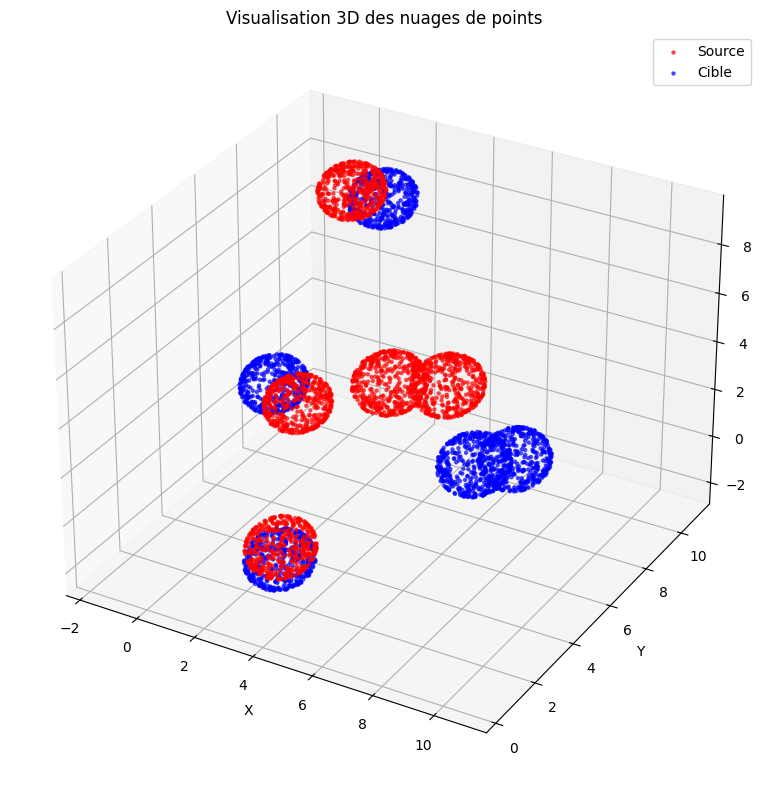


=== Étape 2 : Segmentation en supervoxels ===
Début de la segmentation avec 2400 points...
Généré 9702 graines


Traitement des graines: 100%|██████████| 9702/9702 [00:00<00:00, 66186.75it/s]

Segmentation terminée en 0.19 secondes (5 supervoxels)
Début de la segmentation avec 2400 points...


Généré 10925 graines


Traitement des graines: 100%|██████████| 10925/10925 [00:00<00:00, 79848.97it/s]


Segmentation terminée en 0.18 secondes (4 supervoxels)
Visualisation des supervoxels...


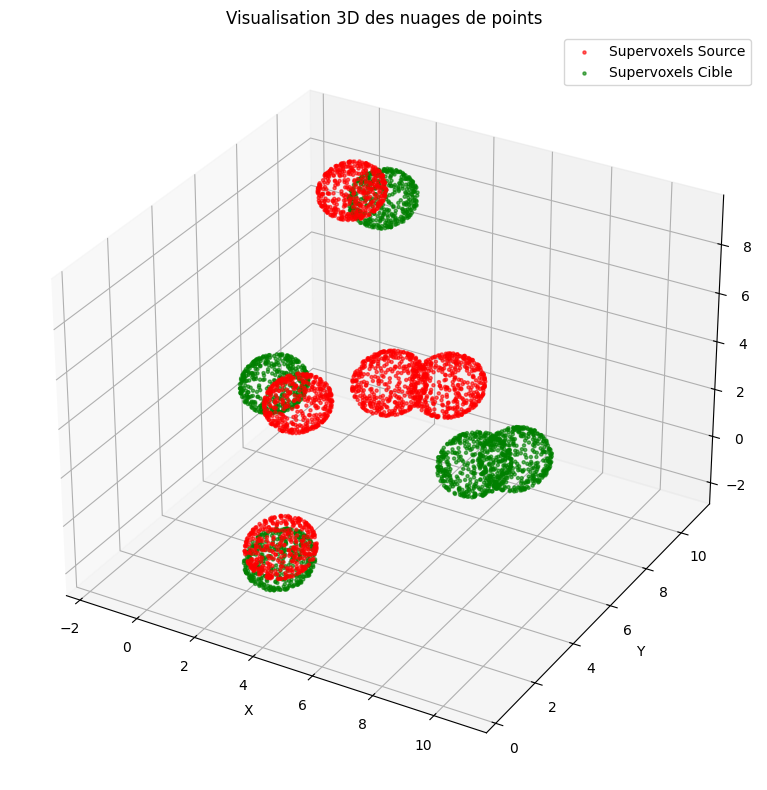


=== Étape 3 : Calcul des descripteurs ===


Calcul des descripteurs simple: 100%|██████████| 4/4 [00:00<00:00, 2364.32it/s]


Descripteurs source : (5, 10)
Descripteurs cible : (4, 10)

=== Étape 4 : Construction des matrices de similarité ===


Construction du graphe d'adjacence: 100%|██████████| 5/5 [00:00<00:00, 11107.80it/s]


Graphe d'adjacence construit avec 5 nœuds et 3 arêtes


...

Graphe d'adjacence construit avec 4 nœuds et 4 arêtes
Matrice de similarité des nœuds : (5, 4)


Calcul des descripteurs d'arêtes: 100%|██████████| 4/4 [00:00<00:00, 14993.04it/s]


Matrice de similarité des arêtes : (3, 4)

=== Étape 5 : Appariement de graphes avec Frank-Wolfe ===
Avertissement : Matrice de similarité rectangulaire 5x4. Utilisation de min(n,m).


Itérations Frank-Wolfe:   0%|          | 0/50 [00:00<?, ?it/s]


ValueError: The truth value of an array with more than one element is ambiguous. Use a.any() or a.all()

In [56]:
# ============================================================================
# CELL 13: EXÉCUTION DE L'EXEMPLE
# ============================================================================

# Exemple avec des données synthétiques
print('Création des données de test...')
#source_pcd, target_pcd, ground_truth_transform = create_test_data(num_points=500, noise_level=0.005)
source_pcd, target_pcd, ground_truth_transform = create_test_data_from_file(
    input_pcd_path='nuclei.pcd',  # Fichier d'entrée
    output_source_path='source.pcd',  # Fichier source (non transformé)
    output_target_path='target.pcd',  # Fichier cible (transformé + bruit)
    noise_level=0.005,                 # Niveau de bruit
    rotation_range=(0, np.pi/8),      # Rotation limitée à 90 degrés
    translation_range=(-0.05, 0.05), # Translation limitée
    save_files=True                   # Sauvegarder les fichiers
)
# Sauvegarde des données temporaires
save_test_data(source_pcd, target_pcd, 'temp_source.pcd', 'temp_target.pcd')

# Exécution de la pipeline complète
print('\nExécution de la pipeline complète sur des données synthétiques...')
results = register_point_clouds(
    'temp_source.pcd', 'temp_target.pcd',
    voxel_resolution=0.1,
    seed_resolution=0.5,
    descriptor_type='simple',
    num_bins=10,
    use_icp=True,
    use_ransac=True,
    frank_wolfe_max_iter=50,
    ransac_n=50,
    visualize=True
)

# Comparaison avec la vérité terrain
if 'transform' in results:
    estimated_transform = results['transform']

    rotation_error = np.linalg.norm(estimated_transform[:3, :3] - ground_truth_transform[:3, :3])
    translation_error = np.linalg.norm(estimated_transform[:3, 3] - ground_truth_transform[:3, 3])

    print(f'\nComparaison avec la vérité terrain :')
    print(f'Erreur de rotation : {rotation_error:.6f}')
    print(f'Erreur de translation : {translation_error:.6f}')

# Nettoyage des fichiers temporaires
import os
if os.path.exists('temp_source.pcd'):
    os.remove('temp_source.pcd')
if os.path.exists('temp_target.pcd'):
    os.remove('temp_target.pcd')